# 09 · In-code, output-time PCA coefficients — verification

Verifies the PCA coefficients L-GALAXIES writes **from inside the C code at snapshot-output time** (`COMP_PCA_COEFFICIENTS`) against the Python post-processing and against L-GALAXIES' own stored `Mag`.

**Execution model — guarded.** This notebook needs L-GALAXIES binary output, produced by a run with the flag enabled. Millennium-II output lives on an external drive and is not present here, so `get_tree("MRII")` fails immediately with the missing paths rather than part-way through.

This notebook:

1. Reads the PCA coefficients L-GALAXIES writes in-code at snapshot-output time from the binary output file. They are computed by convolving each galaxy's stored star-formation history with the PCA(age, Z) grid — the same code path as L-GALAXIES' post-processed magnitudes (`code/pca_sed.c` → `save.c`, next to `post_process_spec_mags`).
2. Reconstructs galaxy SEDs from those coefficients and computes synthetic SDSS *ugriz* AB magnitudes.
3. Compares them against L-GALAXIES' stored `Mag` (intrinsic, from its own SSP tables) and against the Python post-processing product named by `TREE.coeffs_name`.
4. Provides an interactive SED explorer for any galaxy in the matched sample.

> **Terminology.** These 50 numbers are a compact spectral *representation* computed at output time. They are **not** a live, wavelength-resolved SED carried as a state variable during the run, and they are never fed back into the physics — they live in `struct GALAXY_OUTPUT` and are computed in the `POST_PROCESS_MAGS` branch of `save.c`. The phrase "on-the-fly SED" overstates this and is not used anywhere in this notebook; the correct register is **in-code, output-time PCA spectral coefficients**. See `documents/onthefly_factcheck.md` for the full analysis and ResearchPlan_2026 §2.2 for why it matters to the papers.

**Pre-requisites** (run once, before this notebook):

```bash
# 1. Export the PCA(age, Z) grid as a C-readable binary
python scripts/export_pca_for_lgalaxies.py

# 2. Build L-GALAXIES with the flag
#    In My_Makefile_options: uncomment  OPT += -DCOMP_PCA_COEFFICIENTS
make clean && make

# 3. Run L-GALAXIES with the parameter file matching TREE
#    MRI : ./L-Galaxies ./input/input_MR_W1_PLANCK_LGals2020_DM.par
#    MRII: ./L-Galaxies ./input/input_MRII_W1_PLANCK_LGals2020_DM.par

# 4. Run the Python post-processing, for the comparison in section 8.
#    --sample and --output are both REQUIRED and have no defaults; the script
#    refuses to overwrite an existing product without --overwrite, and refuses a
#    sample/output pair that names different simulations.
python scripts/process_lgalaxies.py \
    --sample "$LGAL/output/samples/<the sample named in CFG['sample']>" \
    --output "data/<the file named in CFG['coeffs']>" \
    --backend bc03
```


## Merger tree

Set `TREE` below. Every per-tree constant comes from `galspectra.trees`, so the
tree is chosen in exactly one place and the sample file cannot disagree with the
coefficient product.


In [1]:
# ── Merger tree ─────────────────────────────────────────────────────────────
# "MR"   Millennium-I   (default)
# "MRII" Millennium-II  — trees live on an external drive and there is no
#                         galaxy_table_MRII.npz, so this is often unavailable.
#
# Every per-tree constant comes from galspectra.trees, so the sample file and the
# coefficient product cannot disagree about which simulation this is. Selecting a
# tree whose data is absent fails immediately, naming the path: TREE.require()
# never falls back to the other tree, because that would mean every number below
# quietly described a different simulation from the one in the heading.
from galspectra.trees import get_tree

TREE = get_tree("MR")          # Millennium-I
print(f"Tree: {TREE.label}  ({TREE.pretty})")


Tree: MR  (Millennium-I)


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# ── Tree file selection ─────────────────────────────────────────────────────
# Set FILE_NR to one file number from TREE.file_range, or None for all of them.
FILE_NR = None

# ── Repo paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR     = Path('.').resolve()
GALSPECTRA_ROOT  = NOTEBOOK_DIR.parent
LGAL_ROOT        = GALSPECTRA_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
LGAL_PYTHON      = LGAL_ROOT / 'AuxCode' / 'Python'
FILTER_DIR       = LGAL_ROOT / 'SpecPhotTables' / 'Filters'

SAMPLE_FILE   = TREE.require(TREE.sample_path(LGAL_ROOT),
                             'the L-GALAXIES galaxy sample')
POSTPROC_FILE = TREE.require(TREE.coeffs_path(GALSPECTRA_ROOT / 'data'),
                             'the post-processed PCA coefficient product')
PCA_FILE      = TREE.require(GALSPECTRA_ROOT / 'data' / 'pca_results_bc03.npz',
                             'the PCA basis')

sys.path.insert(0, str(GALSPECTRA_ROOT / 'src'))
from galspectra.csp.reconstruct import reconstruction_sed_from_pca
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import C_ANG_S

# ── Physical constants ─────────────────────────────────────────────────────
hub_h            = 0.673
DM_PART_MSUNh    = TREE.dm_particle_msun_h   # DM particle mass [Msun/h]
PART_RES         = 20.0                      # particles; same for both trees
SM_RES_MSUN      = TREE.sm_resolution_msun   # stellar mass cut [Msun]
_D_10PC_CM       = 3.0857e19
_FOUR_PI_10PC_SQ = 4.0 * np.pi * _D_10PC_CM**2

BANDS       = ['u', 'g', 'r', 'i', 'z']
BAND_IDX    = {b: i for i, b in enumerate(BANDS)}
BAND_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
               'i': '#FF9800', 'z': '#795548'}
BAND_LEFF   = {'u': 3551, 'g': 4686, 'r': 6165, 'i': 7481, 'z': 8931}   # Å

FILE_RANGE = TREE.file_range
if isinstance(FILE_NR, int) and FILE_NR not in FILE_RANGE:
    raise ValueError(
        f'FILE_NR = {FILE_NR} is not in the {TREE.pretty} file range '
        f'{FILE_RANGE.start}-{FILE_RANGE.stop - 1}.')
mode_label = (f'file {FILE_NR}' if isinstance(FILE_NR, int)
              else f'all files ({FILE_RANGE.start}-{FILE_RANGE.stop - 1})')
print(f'L-GALAXIES root : {LGAL_ROOT}')
print(f'GALsPeCtrA root : {GALSPECTRA_ROOT}')
print(f'Tree            : {TREE.label}  ({TREE.pretty})')
print(f'Mode            : {mode_label}')

for label, p in [('Sample', SAMPLE_FILE), ('Post-proc', POSTPROC_FILE),
                 ('PCA model', PCA_FILE)]:
    print(f'  {label:<14} ok  {p.name}')

# ── L-GALAXIES binary output ───────────────────────────────────────────────
# The input that is absent for Millennium-II on this machine. Fail here,
# naming the paths, rather than part-way through the comparison.
#
# BINARY_FILES is built once, by TREE.output_paths(), and reused by the loader
# below. Building the path a second time is what let a hard-coded
# Millennium-II path survive inside a Millennium-I notebook.
#
# _file_nrs comes from TREE.file_numbers(), which output_paths() also calls, so the
# numbers and the paths are the same list in the same order by construction. The
# loader below zips them together; when this line was missing it raised NameError and
# took every cell after it with it.
BINARY_FILES = TREE.output_paths(LGAL_ROOT, FILE_NR)
_file_nrs    = TREE.file_numbers(FILE_NR)
OUT_DIR      = BINARY_FILES[0].parent
files_to_check = BINARY_FILES
missing = [p for p in files_to_check if not p.exists()]
if missing:
    shown = '\n    '.join(str(p) for p in missing[:5])
    more  = '' if len(missing) <= 5 else f'\n    ... and {len(missing) - 5} more'
    raise FileNotFoundError(
        f'tree {TREE.label!r} ({TREE.pretty}) needs L-GALAXIES binary output, and '
        f'{len(missing)} of {len(files_to_check)} file(s) are missing:\n'
        f'    {shown}{more}\n'
        f'These are produced by running L-GALAXIES with COMP_PCA_COEFFICIENTS '
        f'enabled (see the pre-requisites above). If this tree\'s output lives '
        f'on an external drive, mount it; otherwise select a tree whose output '
        f'is present.')
print(f'  {"Binary file(s)":<14} ok  {len(files_to_check)} file(s) in {OUT_DIR}')


L-GALAXIES root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/L-GALAXIES/LGalaxies2020_PublicRepository-master
GALsPeCtrA root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/GALsPeCtrA
Tree            : MR  (Millennium-I)
Mode            : all files (5-5)
  Sample         ok  Planck_Mil-I_snapshots_default_test3_z0.00-0.00_All.npy
  Post-proc      ok  lgalaxies_sed_coeffs_bc03.npz
  PCA model      ok  pca_results_bc03.npz
  Binary file(s) ok  1 file(s) in /Users/suteepornz/Documents/Suttikoon/Research_Projects/L-GALAXIES/LGalaxies2020_PublicRepository-master/output


## 1. Load PCA model data and SDSS filters

In [3]:
# ── PCA model ──────────────────────────────────────────────────────────────
pca          = np.load(PCA_FILE, allow_pickle=True)
pca_wave     = pca['wave']                # (831,) Å, 805–29950
pca_comps    = pca['components']          # (50, 831)  PCA eigenvectors
pca_mean     = pca['mean']                # (831,)     mean of normalised training SEDs
pca_variance = pca['variance']            # (50,)      variance explained per PC
norm_meta    = pca['norm'].item()         # dict: 'mean' (831,), 'std' (831,)
norm_mean    = norm_meta['mean']          # per-wavelength mean before PCA
norm_std     = norm_meta['std']           # per-wavelength std  before PCA
pca_cumvar   = np.cumsum(pca_variance)

N_PC   = pca_comps.shape[0]
N_WAVE = len(pca_wave)

print(f'PCA: {N_PC} components  |  wavelength grid: {N_WAVE} bins  '
      f'({pca_wave[0]:.0f}–{pca_wave[-1]:.0f} Å)')
print(f'Variance explained: PC1 = {pca_cumvar[0]*100:.1f}%  '
      f'PC10 = {pca_cumvar[9]*100:.2f}%  '
      f'PC50 = {pca_cumvar[-1]*100:.4f}%')

# ── SDSS filters ───────────────────────────────────────────────────────────
filters = load_sdss_filters(FILTER_DIR)
print(f'\nFilters loaded: {list(filters.keys())}')
for b, (wf, tf) in filters.items():
    print(f'  {b}: {wf[0]:.0f}–{wf[-1]:.0f} Å  ({len(wf)} points)')

PCA: 50 components  |  wavelength grid: 831 bins  (805–29950 Å)
Variance explained: PC1 = 68.2%  PC10 = 99.99%  PC50 = 100.0000%

Filters loaded: ['u', 'g', 'r', 'i', 'z']
  u: 2980–4130 Å  (47 points)
  g: 3630–5830 Å  (89 points)
  r: 5380–7230 Å  (75 points)
  i: 6430–8630 Å  (89 points)
  z: 7730–11230 Å  (141 points)


## 2. Load L-GALAXIES binary output (with in-code, output-time PCA coefficients)

In [4]:
sys.path.insert(0, str(LGAL_PYTHON))
from LGalaxy_snapshots import LGalaxiesStruct

# Reuse the paths the guard above already validated. Do not rebuild them.
file_list = list(zip(_file_nrs, BINARY_FILES))

chunks    = []
total_raw = 0
struct_sz = None

for fnr, fpath in file_list:
    fsize = fpath.stat().st_size
    with open(fpath, 'rb') as f:
        n_trees = int(np.fromfile(f, np.int32, 1)[0])
        n_gals  = int(np.fromfile(f, np.int32, 1)[0])
        _       = np.fromfile(f, np.int32, n_trees)
        chunk   = np.fromfile(f, LGalaxiesStruct, n_gals)
    chunks.append(chunk)
    total_raw += n_gals
    if struct_sz is None:
        struct_sz = LGalaxiesStruct.itemsize
    if len(file_list) == 1 or fnr % 10 == 0 or fnr == file_list[-1][0]:
        print(f'  File {fnr}: {n_gals:,} galaxies  ({fsize/1e6:.0f} MB)')

gals_all  = np.concatenate(chunks) if len(chunks) > 1 else chunks[0]
n_nonzero = int(np.count_nonzero(gals_all['pca_coeffs'][:, 0]))
print(f'\nLoaded {mode_label}: {total_raw:,} total galaxies  '
      f'(struct size = {struct_sz} B/galaxy)')
print(f'  Non-zero pca_coeffs: {n_nonzero:,} / {total_raw:,}')

# ── Apply selection cuts ───────────────────────────────────────────────────
# Binary stores masses in 10^10 Msun/h — convert thresholds to the same units.
mvir_cut_msun_h = PART_RES * DM_PART_MSUNh               # Msun/h
sm_cut_raw      = SM_RES_MSUN  * hub_h / 1e10             # 10^10 Msun/h
mvir_cut_raw    = mvir_cut_msun_h / (1e10 / hub_h)        # 10^10 Msun/h

sel  = (gals_all['StellarMass'] > sm_cut_raw) & (gals_all['Mvir'] > mvir_cut_raw)
gals = gals_all[sel]

print(f'\nAfter selection cuts ({SM_RES_MSUN:.0e} Msun, '
      f'Mvir >= {mvir_cut_msun_h:.2e} Msun/h):')
print(f'  {len(gals):,} galaxies selected')
print(f'  pca_coeffs dtype: {gals["pca_coeffs"].dtype}  '
      f'shape: {gals["pca_coeffs"].shape}')


  File 5: 29,291 galaxies  (259 MB)

Loaded all files (5-5): 29,291 total galaxies  (struct size = 8852 B/galaxy)
  Non-zero pca_coeffs: 29,291 / 29,291

After selection cuts (1e+09 Msun, Mvir >= 1.92e+10 Msun/h):
  11,396 galaxies selected
  pca_coeffs dtype: float32  shape: (11396, 50)


## 3. Load sample .npy and post-processing data

In [5]:
# The full-sample .npy is used only to align post-processing indices.
# Mag / galaxy properties come directly from the binary file (no sample needed).
sample    = np.load(SAMPLE_FILE, allow_pickle=True)
pp        = np.load(POSTPROC_FILE, allow_pickle=True)
pp_coeffs = pp['pca_coeffs'].astype(np.float64)
pp_gidx   = pp['galaxy_index']
print(f'Sample: {len(sample):,} galaxies (40 files combined — used for pp alignment only)')
print(f'Post-processing: {len(pp_coeffs):,} galaxies')
print(f'  Available synth mags: {[k for k in pp.keys() if "synth" in k]}')


Sample: 11,328 galaxies (40 files combined — used for pp alignment only)
Post-processing: 11,328 galaxies
  Available synth mags: ['synth_mag_u', 'synth_mag_g', 'synth_mag_r', 'synth_mag_i', 'synth_mag_z', 'synth_magdust_u', 'synth_magdust_g', 'synth_magdust_r', 'synth_magdust_i', 'synth_magdust_z']


## 4. Match binary galaxies to sample

Both the binary selection and the sample come from the same model run, so galaxies appear in the same order.  A two-pointer scan with one-step lookahead handles the ±1 galaxy that can appear at the `Mvir` floating-point boundary.

In [6]:
# Use all selected binary galaxies directly for the primary comparison.
# Mag/MagDust/properties come from the binary struct itself.
gals_m  = gals
N_MATCH = len(gals_m)

# Pre-convert masses from binary units (10^10 Msun/h) → Msun
stellar_mass = gals_m['StellarMass'].astype(np.float64) * 1e10 / hub_h
bulge_mass   = gals_m['BulgeMass'].astype(np.float64)   * 1e10 / hub_h

print(f'Galaxies for comparison ({mode_label}): {N_MATCH:,}')

# ── Match to sample for post-processing comparison (secondary) ─────────────
# Sort both arrays by StellarMass before the two-pointer scan so the match
# works regardless of the original ordering of either array.
SM_TOL  = 1e-5
sm_bin  = gals_m['StellarMass']                              # float32, raw units
sm_samp = (sample['StellarMass'] * hub_h / 1e10).astype(np.float32)

_sb  = np.argsort(sm_bin)
_ss  = np.argsort(sm_samp)
_smb = sm_bin[_sb]
_sms = sm_samp[_ss]

matched_si, matched_sj = [], []
i, j = 0, 0
while i < len(_smb) and j < len(_sms):
    sm_b = float(_smb[i]);  sm_s = float(_sms[j])
    tol  = SM_TOL * (sm_b + 1e-30)
    if abs(sm_b - sm_s) < tol:
        matched_si.append(int(_sb[i]));  matched_sj.append(int(_ss[j]))
        i += 1;  j += 1
    elif sm_b < sm_s:
        i += 1
    else:
        j += 1

matched_i_pp = np.array(matched_si, dtype=int)  # indices into gals_m
matched_j_pp = np.array(matched_sj, dtype=int)  # indices into sample
N_PP = len(matched_i_pp)
print(f'Post-processing matches: {N_PP:,} / {N_MATCH:,}  '
      f'({100*N_PP/max(N_MATCH,1):.0f}%)')

if N_PP > 0:
    pp_order       = np.searchsorted(pp_gidx, matched_j_pp)
    valid_align    = pp_gidx[pp_order] == matched_j_pp
    pp_order       = pp_order[valid_align]
    matched_i_pp   = matched_i_pp[valid_align]
    pp_synth_m     = {b: pp[f'synth_mag_{b}'][pp_order]     for b in BANDS}
    pp_synthdust_m = {b: pp[f'synth_magdust_{b}'][pp_order] for b in BANDS}
    _pp_lookup     = {int(gi): pos for pos, gi in enumerate(matched_i_pp)}
    print(f'Post-processing data aligned: {len(pp_order):,} galaxies')
else:
    pp_synth_m     = {b: np.array([]) for b in BANDS}
    pp_synthdust_m = {b: np.array([]) for b in BANDS}
    _pp_lookup     = {}
    print('WARNING: no post-processing matches — pp comparisons will be skipped')


Galaxies for comparison (all files (5-5)): 11,396
Post-processing matches: 11,328 / 11,396  (99%)
Post-processing data aligned: 11,328 galaxies


## 5. Compute total SFH mass and reconstruct SEDs

**Reconstruction formula (vectorised over all galaxies):**
1. $M_\mathrm{tot} = \sum_{\ell=0}^{\mathrm{sfh\_ibin}} (m_\mathrm{disk}[\ell] + m_\mathrm{bulge}[\ell])\;\times\;10^{10}/h$ [M☉]
2. Normalised coefficients: $\tilde{\mathbf{c}} = \mathbf{c}_\mathrm{code} / M_\mathrm{tot}$
3. Normalised SED per M☉: $\tilde{f}_\lambda = \bar{\mu} + \tilde{\mathbf{c}}\,\mathbf{P}$ where $\mathbf{P}$ = PCA eigenvectors
4. Denormalise: $f_\lambda^\mathrm{per\ M_\odot} = \tilde{f}_\lambda\cdot\sigma_\lambda + \mu_\lambda$
5. Scale to 10 pc: $f_\lambda = f_\lambda^\mathrm{per\ M_\odot}\cdot M_\mathrm{tot} / (4\pi\, d_{10}^2)$ [erg/s/Å/cm²]

In [7]:
# ── Total SFH mass per galaxy (vectorised) ─────────────────────────────────
sfh_ibin   = gals_m['sfh_ibin'].astype(int)        # (N,)
n_sfh_bins = gals_m['sfh_DiskMass'].shape[1]        # 20
bin_range  = np.arange(n_sfh_bins)[np.newaxis, :]  # (1, 20)
sfh_mask   = bin_range <= sfh_ibin[:, np.newaxis]   # (N, 20)  valid bins

M_disk_raw  = (gals_m['sfh_DiskMass']  * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_bulge_raw = (gals_m['sfh_BulgeMass'] * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_total     = (M_disk_raw + M_bulge_raw).astype(np.float64) * 1e10 / hub_h   # (N,) Msun

print(f'M_total range: {M_total.min():.2e} – {M_total.max():.2e} Msun')
print(f'  Median M_total = {np.median(M_total):.2e} Msun')

# ── Vectorised SED reconstruction ─────────────────────────────────────────
incode_coeffs  = gals_m['pca_coeffs'].astype(np.float64)   # (N, 50)

# Guard against zero mass (should not occur after selection, but just in case)
good        = M_total > 0
norm_c      = np.zeros_like(incode_coeffs)               # (N, 50)
norm_c[good] = incode_coeffs[good] / M_total[good, np.newaxis]

# sed_norm[i] = pca_mean + norm_c[i] @ pca_comps  (in normalised space)
sed_norm    = pca_mean[np.newaxis, :] + norm_c @ pca_comps   # (N, 831)

# Denormalise: f_per_msun[i, λ] = sed_norm[i, λ] * norm_std[λ] + norm_mean[λ]
sed_per_msun = sed_norm * norm_std[np.newaxis, :] + norm_mean[np.newaxis, :]   # (N, 831)

# Scale to absolute flux at 10 pc
seds        = sed_per_msun * M_total[:, np.newaxis] / _FOUR_PI_10PC_SQ   # (N, 831)

print(f'\nReconstructed {len(seds):,} SEDs  (shape {seds.shape})')
print(f'  Flux range at 5000 Å: {seds[:, np.argmin(np.abs(pca_wave - 5000))].min():.2e} – '
      f'{seds[:, np.argmin(np.abs(pca_wave - 5000))].max():.2e} erg/s/Å/cm²')

M_total range: 1.47e+09 – 8.92e+11 Msun
  Median M_total = 6.31e+09 Msun

Reconstructed 11,396 SEDs  (shape (11396, 831))
  Flux range at 5000 Å: 1.46e-02 – 1.23e+01 erg/s/Å/cm²


## 6. Compute synthetic AB magnitudes (batch)

Integrates each SED against the SDSS filter curves using the standard AB formula:
$$m_\mathrm{AB} = -2.5\log_{10}\!\left(\frac{\int f_\nu\, T_\nu\, d\nu}{\int T_\nu\, d\nu}\right) - 48.6$$

In [8]:
def compute_ab_mag_batch(wave, seds_flam, filters):
    """Vectorised AB magnitudes.  seds_flam: (N, N_wave) in erg/s/Å/cm²."""
    nu_hz = C_ANG_S / wave            # (N_wave,) descending
    idx   = np.argsort(nu_hz)         # ascending frequency order
    nu_s  = nu_hz[idx]                # (N_wave,)
    # f_ν = f_λ * λ² / c
    fnu   = seds_flam * (wave**2 / C_ANG_S)[np.newaxis, :]   # (N, N_wave)
    fnu_s = fnu[:, idx]               # (N, N_wave) in ascending ν order

    mags = {}
    for name, (wf, tf) in filters.items():
        T     = np.interp(wave, wf, tf, left=0., right=0.)[idx]  # (N_wave,)
        if T.sum() == 0:
            mags[name] = np.full(len(seds_flam), np.nan)
            continue
        num   = np.trapezoid(fnu_s * T[np.newaxis, :], nu_s, axis=1)  # (N,)
        den   = float(np.trapezoid(T, nu_s))
        with np.errstate(divide='ignore', invalid='ignore'):
            mags[name] = np.where(num > 0,
                                  -2.5 * np.log10(num / den) - 48.6,
                                  np.nan)
    return mags

print('Computing synthetic magnitudes for all matched galaxies...')
synth_mags = compute_ab_mag_batch(pca_wave, seds, filters)  # dict {band: (N,)}

for b in BANDS:
    valid = np.isfinite(synth_mags[b])
    print(f'  {b}: {valid.sum():,} finite   '
          f'median = {np.nanmedian(synth_mags[b]):.2f} mag')

Computing synthetic magnitudes for all matched galaxies...
  u: 11,396 finite   median = -17.67 mag
  g: 11,396 finite   median = -18.77 mag
  r: 11,396 finite   median = -19.22 mag
  i: 11,396 finite   median = -19.43 mag
  z: 11,396 finite   median = -19.61 mag


## 7. In-code synthetic mags vs L-GALAXIES intrinsic `Mag`

`Mag` from L-GALAXIES is computed by the SSP spectral synthesis (`post_process_spec_mags`).
The PCA reconstruction should reproduce these to within ≲ 0.05 mag.

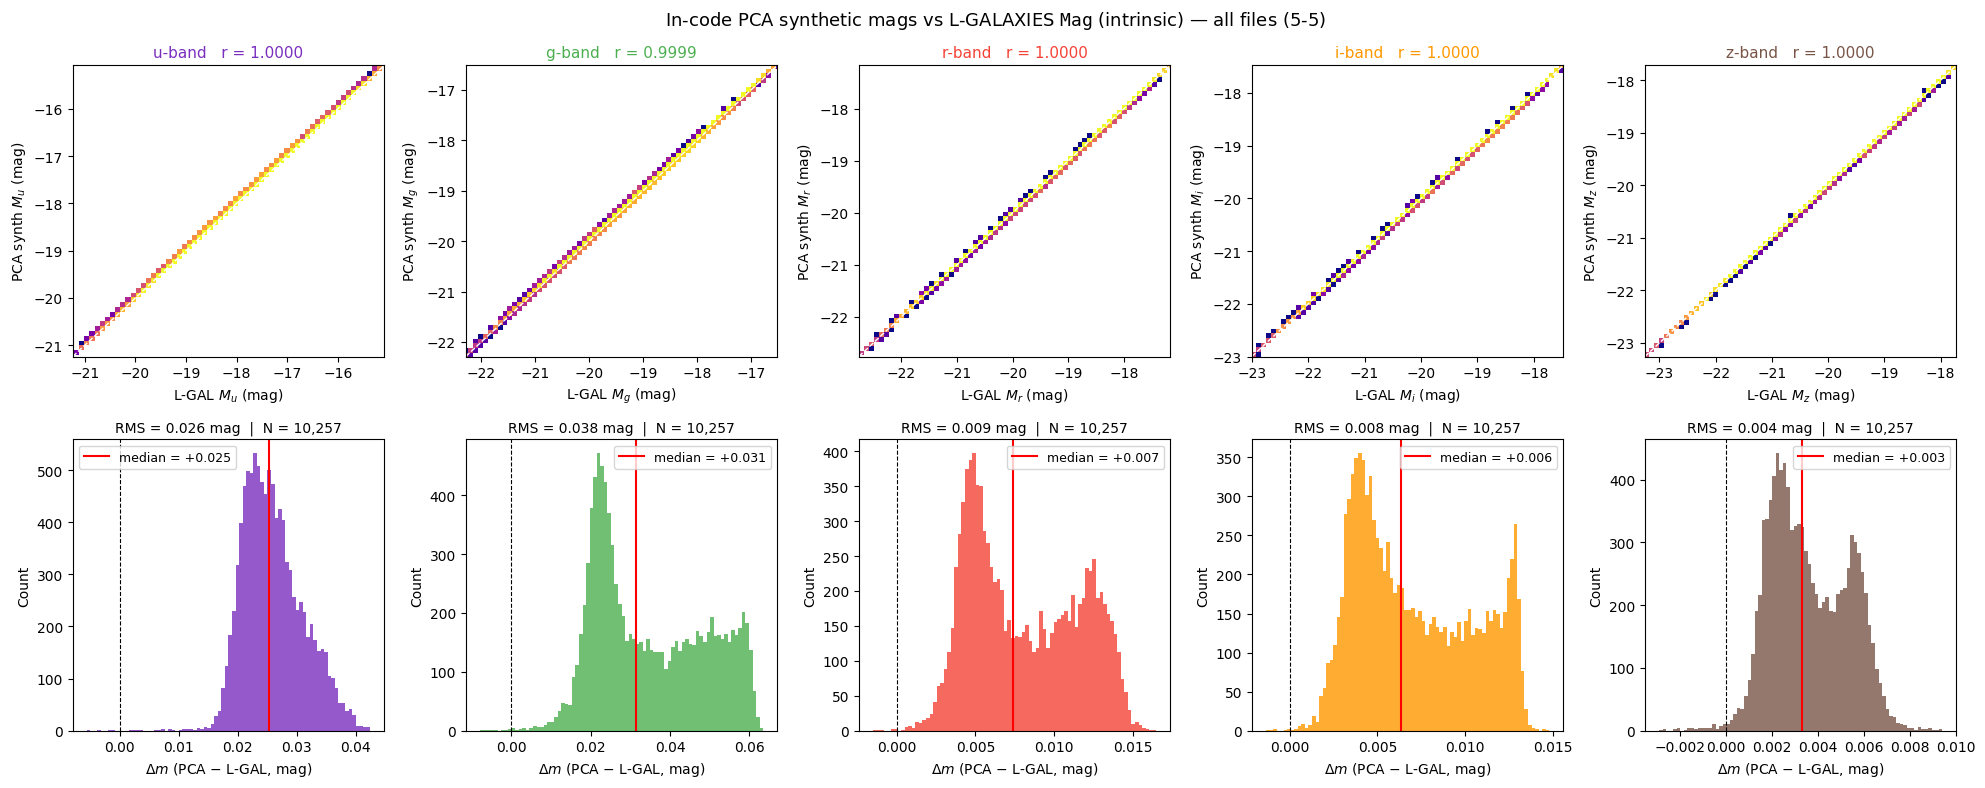

In [9]:
lgal_mag = gals_m['Mag']   # (N, 5) intrinsic SDSS ugriz AB mag — direct from binary

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'In-code PCA synthetic mags vs L-GALAXIES $\\mathtt{{Mag}}$ (intrinsic) — {mode_label}',
             fontsize=13)

for col, b in enumerate(BANDS):
    bi     = BAND_IDX[b]
    synth  = synth_mags[b]
    stored = lgal_mag[:, bi]
    valid  = np.isfinite(synth) & (stored < 90.0)
    x, y   = synth[valid], stored[valid]
    delta  = x - y

    ax = axes[0, col]
    ax.hist2d(y, x, bins=80, cmin=1, cmap='plasma',
              norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
    xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
    ax.plot(xlim, xlim, 'w--', lw=1.0, label='1:1')
    ax.set_xlim(*xlim); ax.set_ylim(*xlim)
    ax.set_xlabel(f'L-GAL $M_{b}$ (mag)', fontsize=10)
    ax.set_ylabel(f'PCA synth $M_{b}$ (mag)', fontsize=10)
    r, _ = stats.pearsonr(x, y)
    ax.set_title(f'{b}-band   r = {r:.4f}', color=BAND_COLORS[b], fontsize=11)

    ax2 = axes[1, col]
    ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax2.axvline(0, color='k', lw=0.8, ls='--')
    ax2.axvline(np.median(delta), color='red', lw=1.5,
                label=f'median = {np.median(delta):+.3f}')
    ax2.set_xlabel(r'$\Delta m$ (PCA $-$ L-GAL, mag)', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.legend(fontsize=9)
    rms = np.sqrt(np.mean(delta**2))
    ax2.set_title(f'RMS = {rms:.3f} mag  |  N = {valid.sum():,}', fontsize=10)

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / f'pca_incode_vs_lgal_intrinsic_file{FILE_NR}.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. In-code mags vs post-processing `synth_mag_*`

Both use the same PCA model and the same galaxy SFH data, so the agreement should be
near-perfect (differences arise only from float32 → float64 rounding in the C code).

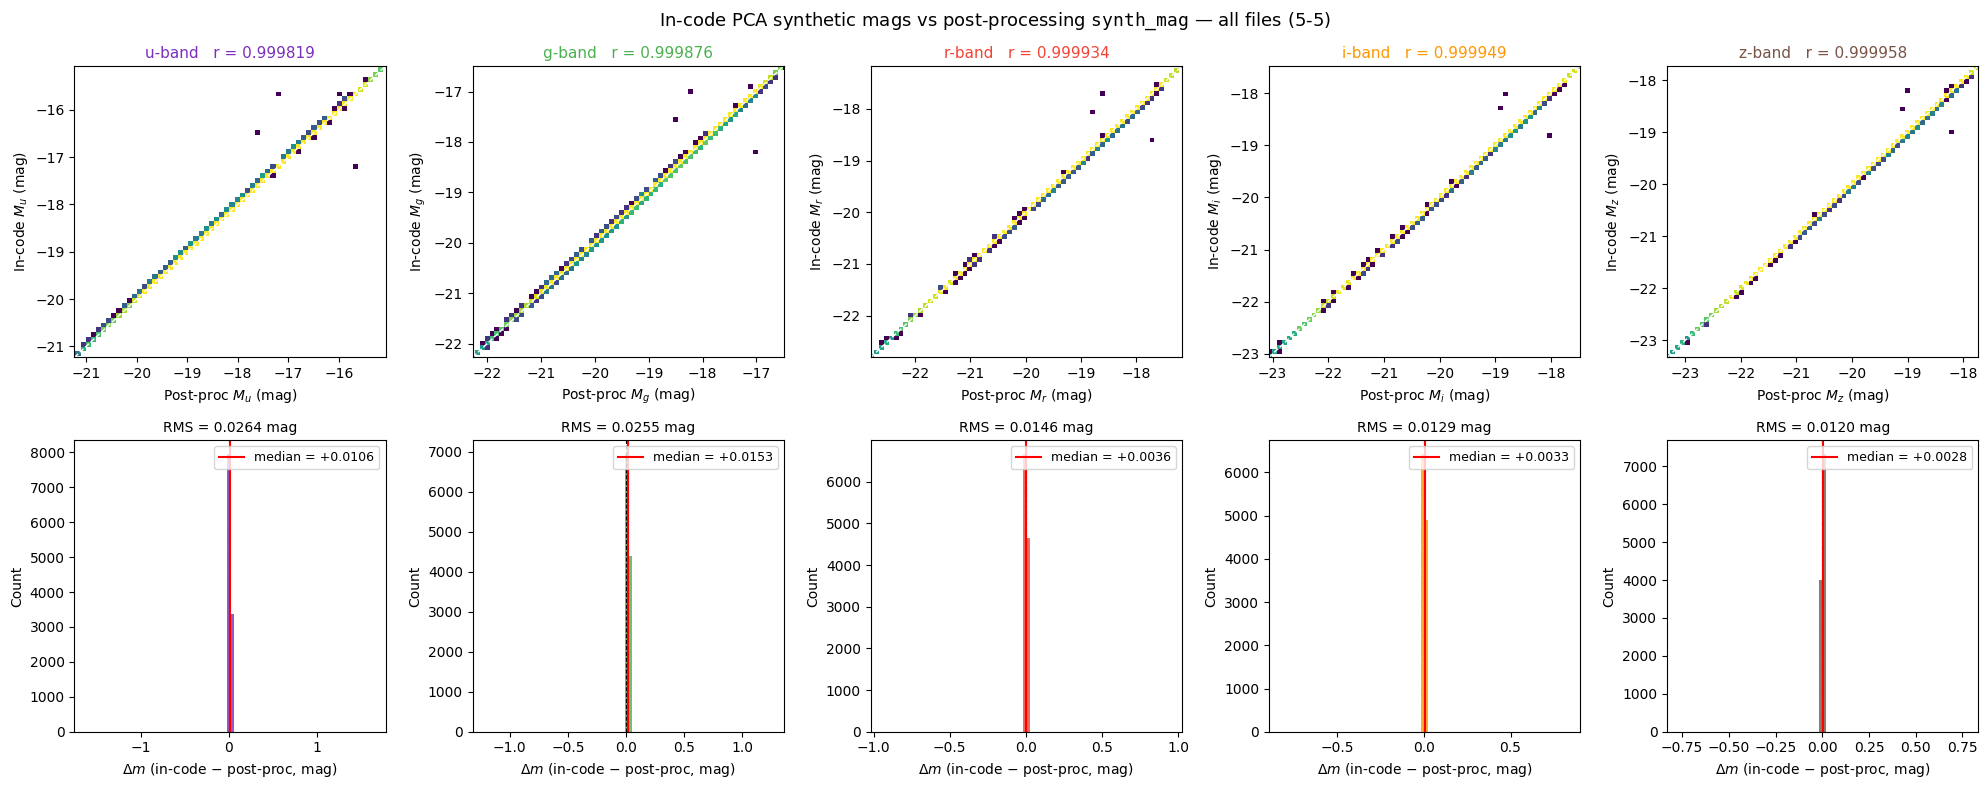

In [10]:
if N_PP == 0:
    print('Skipping: no post-processing matches for this file.')
else:
    synth_pp = {b: synth_mags[b][matched_i_pp] for b in BANDS}  # in-code coefficients for matched gals

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'In-code PCA synthetic mags vs post-processing $\\mathtt{{synth\\_mag}}$ — {mode_label}',
                 fontsize=13)

    for col, b in enumerate(BANDS):
        synth  = synth_pp[b]
        stored = pp_synth_m[b]
        valid  = np.isfinite(synth) & np.isfinite(stored) & (stored < 90.0)
        x, y   = synth[valid], stored[valid]
        delta  = x - y

        ax = axes[0, col]
        ax.hist2d(y, x, bins=80, cmin=1, cmap='viridis',
                  norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
        xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
        ax.plot(xlim, xlim, 'w--', lw=1.0)
        ax.set_xlim(*xlim); ax.set_ylim(*xlim)
        ax.set_xlabel(f'Post-proc $M_{b}$ (mag)', fontsize=10)
        ax.set_ylabel(f'In-code $M_{b}$ (mag)', fontsize=10)
        r, _ = stats.pearsonr(x, y)
        ax.set_title(f'{b}-band   r = {r:.6f}', color=BAND_COLORS[b], fontsize=11)

        ax2 = axes[1, col]
        ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
        ax2.axvline(0, color='k', lw=0.8, ls='--')
        ax2.axvline(np.median(delta), color='red', lw=1.5,
                    label=f'median = {np.median(delta):+.4f}')
        ax2.set_xlabel(r'$\Delta m$ (in-code $-$ post-proc, mag)', fontsize=10)
        ax2.set_ylabel('Count', fontsize=10)
        ax2.legend(fontsize=9)
        rms = np.sqrt(np.mean(delta**2))
        ax2.set_title(f'RMS = {rms:.4f} mag', fontsize=10)

    plt.tight_layout()
    plt.savefig(GALSPECTRA_ROOT / 'data' / f'pca_incode_vs_postproc_file{FILE_NR}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## 9. Summary statistics

In [11]:
synth_pp = {b: synth_mags[b][matched_i_pp] for b in BANDS} if N_PP > 0 else {}

print(f'{"Band":<6}  {"":=<58}')
print(f'{"Band":<6}  {"In-code vs L-GAL Mag":^28}  {"In-code vs post-proc":^28}')
print(f'{"":<6}  {"median Δ":>10} {"RMS":>8} {"r":>8}  {"median Δ":>10} {"RMS":>8} {"r":>8}')
print(f'{"":<6}  {"-"*28}  {"-"*28}')

for b in BANDS:
    bi    = BAND_IDX[b]
    synth = synth_mags[b]
    lgal  = gals_m['Mag'][:, bi]

    vl = np.isfinite(synth) & (lgal < 90.0)
    dl = synth[vl] - lgal[vl]
    r_l, _ = stats.pearsonr(synth[vl], lgal[vl])

    if N_PP > 0:
        sp   = synth_pp[b]
        pp_s = pp_synth_m[b]
        vp   = np.isfinite(sp) & np.isfinite(pp_s)
        dp   = sp[vp] - pp_s[vp]
        r_p, _ = stats.pearsonr(sp[vp], pp_s[vp])
        pp_str = f'{np.median(dp):>+10.4f} {np.sqrt(np.mean(dp**2)):>8.4f} {r_p:>8.6f}'
    else:
        pp_str = f'{"(no match)":>10} {"--":>8} {"--":>8}'

    print(f'{b:<6}  {np.median(dl):>+10.3f} {np.sqrt(np.mean(dl**2)):>8.3f} {r_l:>8.4f}  {pp_str}')

print(f'{"":<6}  {"":-<58}')
print('\nNotes:')
print('  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences')
print('  vs post-proc: near-zero means the in-code C path ≈ Python post-processing (numerical check)')


Band    ==========================================================
Band        In-code vs L-GAL Mag          In-code vs post-proc    
          median Δ      RMS        r    median Δ      RMS        r
        ----------------------------  ----------------------------
u           +0.025    0.026   1.0000     +0.0106   0.0264 0.999819
g           +0.031    0.038   0.9999     +0.0153   0.0255 0.999876
r           +0.007    0.009   1.0000     +0.0036   0.0146 0.999934
i           +0.006    0.008   1.0000     +0.0033   0.0129 0.999949
z           +0.003    0.004   1.0000     +0.0028   0.0120 0.999958
        ----------------------------------------------------------

Notes:
  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences
  vs post-proc: near-zero means the in-code C path ≈ Python post-processing (numerical check)


## 10. Colour–magnitude and colour–colour diagnostics

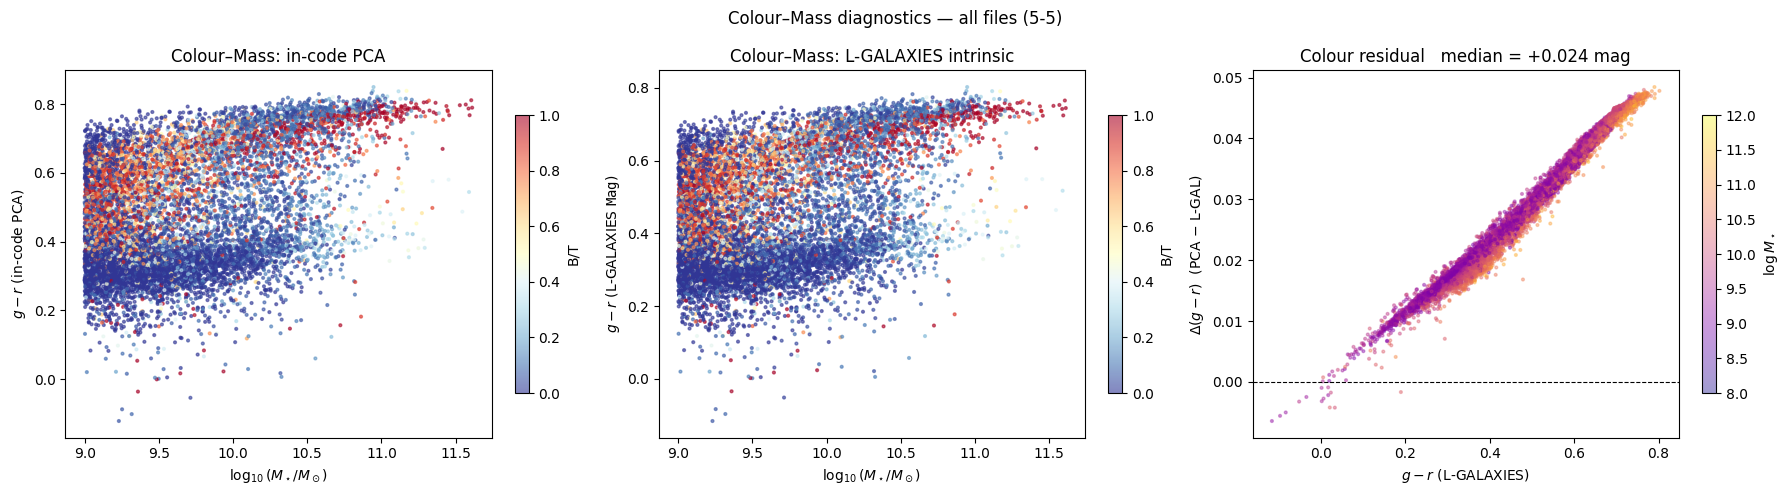

In [22]:
# stellar_mass and bulge_mass are pre-converted to Msun (defined in cell 4)
log_mstar  = np.log10(stellar_mass + 1e-10)
bt         = bulge_mass / (stellar_mass + 1e-10)
lgal_mag   = gals_m['Mag']   # (N, 5) from binary

gr_incode  = synth_mags['g'] - synth_mags['r']
ur_incode  = synth_mags['u'] - synth_mags['r']
gr_lgal = lgal_mag[:, 1] - lgal_mag[:, 2]
ur_lgal = lgal_mag[:, 0] - lgal_mag[:, 2]

valid_both = np.isfinite(gr_incode) & (lgal_mag[:, 2] < 90.)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Colour–Mass diagnostics — {mode_label}', fontsize=12)

ax = axes[0]
sc = ax.scatter(log_mstar[valid_both], gr_incode[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=4, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (in-code PCA)')
ax.set_title('Colour–Mass: in-code PCA')

ax = axes[1]
sc = ax.scatter(log_mstar[valid_both], gr_lgal[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=4, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (L-GALAXIES $\mathtt{Mag}$)')
ax.set_title('Colour–Mass: L-GALAXIES intrinsic')

ax = axes[2]
d_gr = gr_incode[valid_both] - gr_lgal[valid_both]
sc = ax.scatter(gr_lgal[valid_both], d_gr,
                c=log_mstar[valid_both], cmap='plasma', s=4, alpha=0.4,
                vmin=8, vmax=12)
plt.colorbar(sc, ax=ax, label=r'$\log M_\star$', fraction=0.03)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$g - r$ (L-GALAXIES)')
ax.set_ylabel(r'$\Delta(g-r)$  (PCA $-$ L-GAL)')
ax.set_title(f'Colour residual   median = {np.median(d_gr):+.3f} mag')

plt.tight_layout()
plt.show()


## 11. Interactive SED explorer

Select any galaxy from the matched sample.  The plot shows:
- **Black solid line** — SED reconstructed from the in-code PCA coefficients
- **Shaded regions** — SDSS *ugriz* filter bandpasses (scaled for visibility)
- **Markers** — synthetic AB magnitudes (in-code ✦) and L-GALAXIES stored `Mag` (◆)

> **Tip:** A slider value of 0 is the first matched galaxy; use the galaxy properties panel to find interesting objects.

In [13]:
from ipywidgets import interact, IntSlider, Checkbox, Layout

def plot_galaxy_sed(galaxy_idx=0, log_scale=True, show_residuals=True):
    """Plot the in-code reconstructed SED for the given galaxy index."""
    k     = galaxy_idx
    sed   = seds[k]

    # Galaxy properties — from binary (masses already in Msun via stellar_mass/bulge_mass)
    log_m  = float(np.log10(stellar_mass[k] + 1e-30))
    sfr    = float(gals_m[k]['Sfr'])
    bt_val = float(bulge_mass[k] / (stellar_mass[k] + 1e-10))
    gr_val = float(synth_mags['g'][k] - synth_mags['r'][k])

    incode_m  = {b: float(synth_mags[b][k]) for b in BANDS}
    lgal_m = {b: float(gals_m[k]['Mag'][BAND_IDX[b]]) for b in BANDS}

    # Post-proc mags: only available for galaxies matched to the full sample
    pp_pos = _pp_lookup.get(k, None)
    pp_m   = {b: float(pp_synth_m[b][pp_pos]) if pp_pos is not None else np.nan
              for b in BANDS}

    # ── Layout ────────────────────────────────────────────────────────────
    if show_residuals:
        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1])
        ax_sed = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1])
    else:
        fig, ax_sed = plt.subplots(figsize=(11, 6))
        ax_res = None

    # ── SED panel ─────────────────────────────────────────────────────────
    if log_scale:
        sed_plot = np.maximum(sed, 1e-40)
        ax_sed.semilogy(pca_wave, sed_plot, color='black', lw=2.0,
                        label='In-code PCA SED', zorder=5)
        sed_peak = sed_plot.max()
    else:
        ax_sed.plot(pca_wave, sed, color='black', lw=2.0,
                    label='In-code PCA SED', zorder=5)
        sed_peak = sed.max()

    for band, (wf, tf) in filters.items():
        tf_interp = np.interp(pca_wave, wf, tf, left=0., right=0.)
        peak_idx  = int(np.argmax(tf_interp))
        scale     = sed_peak * 0.20
        if log_scale:
            ax_sed.fill_between(pca_wave, 1e-40,
                                np.maximum(tf_interp * scale, 1e-40),
                                alpha=0.12, color=BAND_COLORS[band])
        else:
            ax_sed.fill_between(pca_wave, 0, tf_interp * scale,
                                alpha=0.12, color=BAND_COLORS[band])
        ax_sed.text(pca_wave[peak_idx], tf_interp[peak_idx] * scale * 1.05,
                    band, ha='center', va='bottom',
                    fontsize=9, color=BAND_COLORS[band], fontweight='bold')

    for band in BANDS:
        leff  = BAND_LEFF[band]
        f_ref = float(np.interp(leff, pca_wave, sed))
        if f_ref > 0 and np.isfinite(incode_m[band]):
            ax_sed.scatter([leff], [f_ref], marker='*', s=150,
                           color=BAND_COLORS[band], zorder=8)

    ax_sed.set_xlim(pca_wave[0], pca_wave[-1])
    ax_sed.set_ylim(1e-17, )
    ax_sed.set_xlabel('Wavelength (Å)', fontsize=12)
    ax_sed.set_ylabel(r'$f_\lambda$  (erg s$^{-1}$ Å$^{-1}$ cm$^{-2}$)', fontsize=12)
    ax_sed.set_title(
        f'Galaxy #{k} ({mode_label})  |  '
        f'$\\log M_\\star = {log_m:.2f}$  |  '
        f'$g-r = {gr_val:.3f}$  |  '
        f'$B/T = {bt_val:.2f}$  |  '
        f'SFR = {sfr:.2f} M☉/yr',
        fontsize=11)
    ax_sed.legend(fontsize=10, loc='upper right')

    # ── Residual bar chart ─────────────────────────────────────────────────
    if ax_res is not None:
        x      = np.arange(len(BANDS))
        w      = 0.35
        d_lgal = [incode_m[b] - lgal_m[b] if lgal_m[b] < 90. else 0. for b in BANDS]
        d_pp   = [incode_m[b] - pp_m[b]   if np.isfinite(pp_m[b]) else 0. for b in BANDS]

        ax_res.bar(x - w/2, d_lgal, w, color='steelblue', alpha=0.85,
                   label='in-code − L-GAL Mag')
        ax_res.bar(x + w/2, d_pp,   w, color='tomato',    alpha=0.85,
                   label='in-code − post-proc')
        ax_res.axhline(0, color='k', lw=0.8)
        ax_res.set_xticks(x)
        ax_res.set_xticklabels(BANDS, fontsize=11)
        ax_res.set_xlabel('SDSS band', fontsize=11)
        ax_res.set_ylabel(r'$\Delta m$ (mag)', fontsize=11)
        ax_res.set_ylim(-0.5, 0.5)
        ax_res.set_title('Magnitude residuals', fontsize=11)
        ax_res.legend(fontsize=9)
        ax_res.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{"Band":<5} {"in-code":>8} {"L-GAL Mag":>10} {"Δ(vs L-GAL)":>12} | '
          f'{"post-proc":>10} {"Δ(vs post)":>12}')
    print('─' * 62)
    for b in BANDS:
        lgal_str = f'{lgal_m[b]:>10.3f}' if lgal_m[b] < 90. else f'{"(n/a)":>10}'
        dlg_str  = f'{incode_m[b]-lgal_m[b]:>+10.3f}' if lgal_m[b] < 90. else f'{"--":>10}'
        pp_str   = f'{pp_m[b]:>10.3f}' if np.isfinite(pp_m[b]) else f'{"(n/a)":>10}'
        dpp_str  = f'{incode_m[b]-pp_m[b]:>+10.4f}' if np.isfinite(pp_m[b]) else f'{"--":>10}'
        print(f'{b:<5} {incode_m[b]:>8.3f} {lgal_str} {dlg_str} | {pp_str} {dpp_str}')


interact(
    plot_galaxy_sed,
    galaxy_idx=IntSlider(min=0, max=N_MATCH - 1, step=1, value=0,
                         description='Galaxy index:',
                         style={'description_width': 'initial'},
                         layout=Layout(width='600px')),
    log_scale=Checkbox(value=True,  description='Log y-axis'),
    show_residuals=Checkbox(value=True, description='Show residuals'),
);


interactive(children=(IntSlider(value=0, description='Galaxy index:', layout=Layout(width='600px'), max=11395,…

## 12. Pick interesting galaxies interactively

Helper to find representative galaxy types within the matched sample, then pass their index to the explorer above.

In [16]:
# stellar_mass and bulge_mass pre-converted to Msun (from cell 4)
log_m   = np.log10(stellar_mass + 1e-30)
sfr_m   = gals_m['Sfr'].astype(float)
bt_m    = bulge_mass / (stellar_mass + 1e-10)
gr_m    = synth_mags['g'] - synth_mags['r']
ssfr_m  = sfr_m / (stellar_mass + 1e-30)
valid_m = np.isfinite(gr_m)

def pick_idx(mask, sort_key=None, pick='median'):
    idx = np.where(mask & valid_m)[0]
    if len(idx) == 0:
        return None
    if sort_key is not None:
        idx = idx[np.argsort(sort_key[idx])]
    return int(idx[-1] if pick == 'max' else idx[len(idx) // 2])

examples = {
    'Massive red elliptical' : pick_idx(bt_m > 0.8, sort_key=log_m, pick='max'),
    'Blue star-forming disk'  : pick_idx((bt_m < 0.2) & (gr_m < 0.3) & (log_m > 9.0)),
    'Green valley'            : pick_idx((gr_m > 0.4) & (gr_m < 0.5) & (log_m > 9.5)),
    'Highest sSFR'            : pick_idx((bt_m < 0.3) & (log_m > 8.5), sort_key=ssfr_m, pick='max'),
    'Lowest mass (above cut)' : pick_idx(valid_m, sort_key=-log_m, pick='max'),
}

print(f'{"Type":<28} {"Idx":>6} {"logM*":>6} {"g-r":>6} {"B/T":>5} {"SFR":>9}')
print('-' * 65)
for name, idx in examples.items():
    if idx is None:
        print(f'{name:<28}  not found in {mode_label}')
        continue
    print(f'{name:<28} {idx:>6d} {log_m[idx]:>6.2f} {gr_m[idx]:>6.3f} '
          f'{bt_m[idx]:>5.2f} {sfr_m[idx]:>9.3f}')
print('\nPass any index above to the galaxy_idx slider in Section 11.')


Type                            Idx  logM*    g-r   B/T       SFR
-----------------------------------------------------------------
Massive red elliptical          706  11.69  0.797  1.00     0.057
Blue star-forming disk         7490   9.55  0.271  0.00     0.718
Green valley                   5261  10.46  0.463  0.03     2.202
Highest sSFR                   8363   9.14  0.059  0.09     3.885
Lowest mass (above cut)        3712   9.00  0.514  0.07     0.056

Pass any index above to the galaxy_idx slider in Section 11.


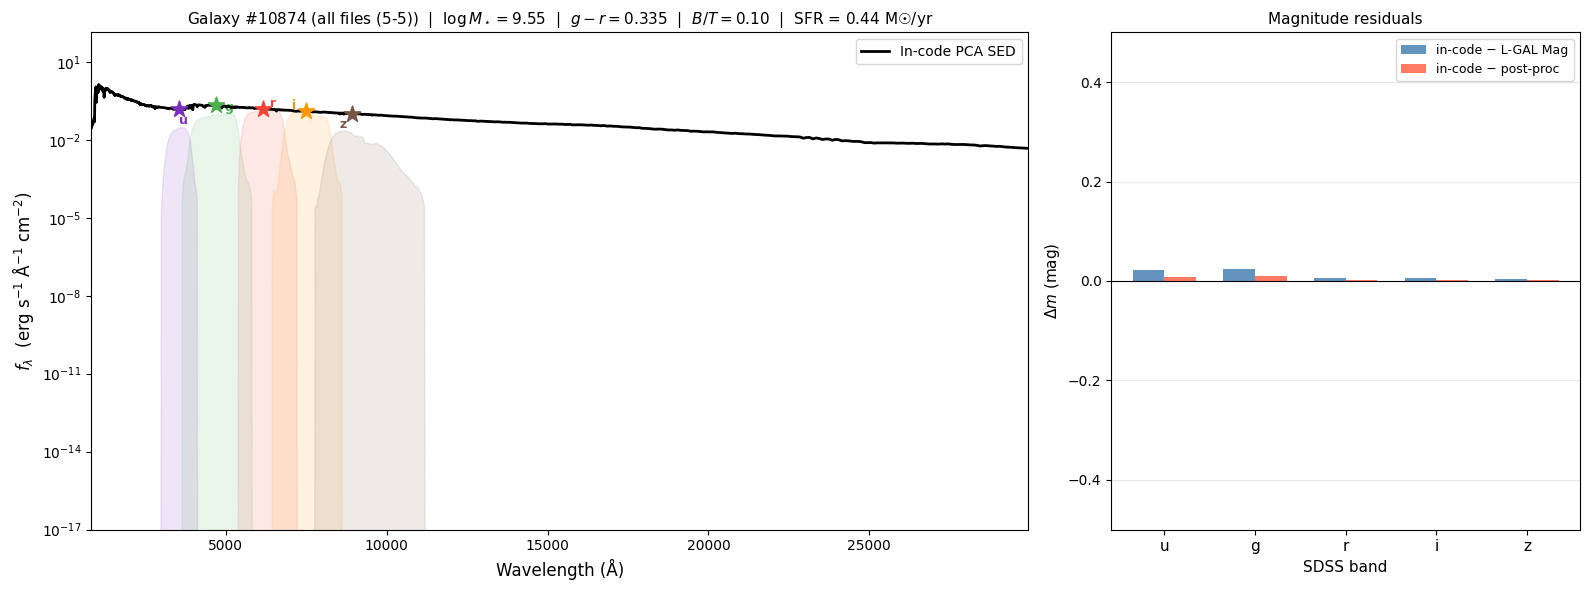

Band   in-code  L-GAL Mag  Δ(vs L-GAL) |  post-proc   Δ(vs post)
──────────────────────────────────────────────────────────────
u      -18.144    -18.166     +0.022 |    -18.153    +0.0087
g      -18.997    -19.021     +0.024 |    -19.008    +0.0106
r      -19.332    -19.338     +0.006 |    -19.334    +0.0026
i      -19.507    -19.512     +0.005 |    -19.509    +0.0026
z      -19.659    -19.662     +0.003 |    -19.661    +0.0022


In [17]:
plot_galaxy_sed(galaxy_idx=min(10874, N_MATCH-1), log_scale=True, show_residuals=True)